# YZM212 Makine Öğrenmesi
## 2. Laboratuvar Ödevi: MLE ile Akıllı Şehir Planlaması

**Ad Soyad:** Enes CAN
**Öğrenci Numarası:** 24290628  
**Tarih:** 15.03.2026

Bu çalışmada, bir dakikada geçen araç sayılarının Poisson dağılımına uyduğu varsayımı altında,
Maximum Likelihood Estimation (MLE) yöntemi ile $\lambda$ parametresi tahmin edilmiştir.
Ayrıca bulunan model, veri histogramı ile karşılaştırılmış ve aykırı değer etkisi incelenmiştir.

In [13]:
import numpy as np
import scipy.optimize as opt
from scipy.stats import poisson
import matplotlib.pyplot as plt

# Bölüm 2: Python ile Sayısal (Numerical) MLE

Bu bölümde verilen trafik verisi kullanılarak Poisson dağılımının $\lambda$ parametresi
hem analitik olarak hem de sayısal optimizasyon ile tahmin edilmektedir.

In [14]:
# Gözlemlenen trafik verisi
# Her eleman, bir dakikada geçen araç sayısını göstermektedir.
traffic_data = np.array([12, 15, 10, 8, 14, 11, 13, 16, 9, 12, 11, 14, 10, 15])

print("Veri seti:", traffic_data)
print("Gözlem sayısı:", len(traffic_data))
print("Veri ortalaması:", np.mean(traffic_data))

Veri seti: [12 15 10  8 14 11 13 16  9 12 11 14 10 15]
Gözlem sayısı: 14
Veri ortalaması: 12.142857142857142


## 2.1 Negatif Log-Olabilirlik Fonksiyonu

Poisson dağılımı için likelihood fonksiyonunun logaritması alınarak log-likelihood elde edilir.
Optimizasyonda sabit olan $\log(k_i!)$ terimi ihmal edilebilir. Bu nedenle negatif log-likelihood
fonksiyonu minimize edilerek MLE tahmini bulunur.

In [15]:
def negative_log_likelihood(lam, data):
    """
    Poisson dağılımı için negatif log-likelihood hesaplar.
    Optimizasyon sırasında sabit kalan log(k!) terimi ihmal edilmiştir.
    """
    # scipy.optimize bazen parametreyi dizi olarak gönderir, bu yüzden float'a çeviriyoruz.
    lam = float(np.atleast_1d(lam)[0])

    # Lambda değeri pozitif olmalıdır.
    if lam <= 0:
        return np.inf

    n = len(data)

    # Log-likelihood:
    # l(lam) = -n*lam + (sum(data))*log(lam) - sabit
    # Negatif log-likelihood:
    nll = n * lam - np.sum(data) * np.log(lam)

    return nll


# Analitik tahmin: Poisson için MLE = örnek ortalaması
lambda_analytic = np.mean(traffic_data)

# Başlangıç tahmini
initial_guess = 1.0

# Sayısal optimizasyon
result = opt.minimize(
    negative_log_likelihood,
    x0=initial_guess,
    args=(traffic_data,),
    bounds=[(0.001, None)]
)

lambda_mle = result.x[0]

print(f"Analitik Tahmin (Ortalama): {lambda_analytic:.6f}")
print(f"Sayısal Tahmin (MLE lambda): {lambda_mle:.6f}")
print(f"Fark: {abs(lambda_analytic - lambda_mle):.12f}")

Analitik Tahmin (Ortalama): 12.142857
Sayısal Tahmin (MLE lambda): 12.142857
Fark: 0.000000239679


# Bölüm 3: Model Karşılaştırma ve Görselleştirme

Bu bölümde bulunan $\lambda$ değeri ile Poisson PMF grafiği çizilecek ve gerçek veri histogramı ile
aynı eksen üzerinde karşılaştırılacaktır.

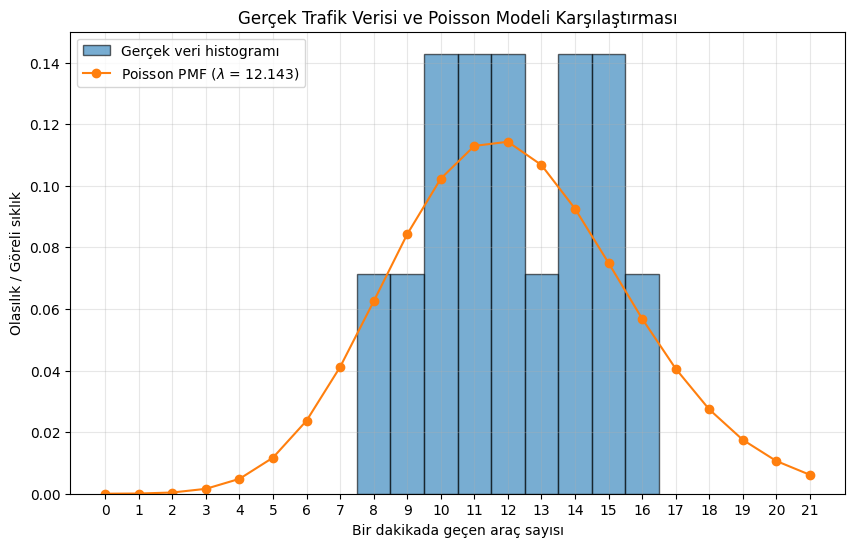

In [16]:
# Poisson PMF için x ekseni değerleri
k_values = np.arange(0, max(traffic_data) + 6)

# Tahmin edilen lambda ile PMF değerleri
pmf_values = poisson.pmf(k_values, mu=lambda_mle)

# Histogram için tam sayılı uygun aralıklar
bins = np.arange(traffic_data.min() - 0.5, traffic_data.max() + 1.5, 1)

plt.figure(figsize=(10, 6))

# Histogramı olasılık yoğunluğu şeklinde normalize ediyoruz
plt.hist(
    traffic_data,
    bins=bins,
    density=True,
    alpha=0.6,
    edgecolor='black',
    label='Gerçek veri histogramı'
)

# Poisson PMF eğrisi
plt.plot(
    k_values,
    pmf_values,
    marker='o',
    label=f'Poisson PMF ($\\lambda$ = {lambda_mle:.3f})'
)

plt.xlabel("Bir dakikada geçen araç sayısı")
plt.ylabel("Olasılık / Göreli sıklık")
plt.title("Gerçek Trafik Verisi ve Poisson Modeli Karşılaştırması")
plt.legend()
plt.xticks(np.arange(0, max(traffic_data) + 6, 1))
plt.grid(alpha=0.3)
plt.show()

## 3.1 Grafik Yorumu

Grafikte histogramın yoğun olarak orta değerler etrafında toplandığı görülmektedir.
Tahmin edilen Poisson PMF eğrisi de benzer şekilde bu merkezi yapıyı takip etmektedir.
Bu durum, modelin veri setine makul düzeyde uyum sağladığını göstermektedir.
Sayısal MLE sonucu ile analitik ortalamanın çakışması da teorik sonucun doğrulandığını göstermektedir.

# Bölüm 4: Outlier (Aykırı Değer) Analizi

Bu bölümde veri setine yanlışlıkla eklenmiş 200 değerinin MLE üzerindeki etkisi incelenecektir.
Poisson dağılımında $\lambda$ tahmini doğrudan ortalamaya bağlı olduğu için aykırı değerlerin etkisi büyüktür.

In [17]:
# Veri setine aykırı değer ekleniyor
traffic_data_outlier = np.append(traffic_data, 200)

# Outlier eklendikten sonraki analitik tahmin
lambda_analytic_outlier = np.mean(traffic_data_outlier)

# Outlier eklendikten sonraki sayısal tahmin
result_outlier = opt.minimize(
    negative_log_likelihood,
    x0=initial_guess,
    args=(traffic_data_outlier,),
    bounds=[(0.001, None)]
)

lambda_mle_outlier = result_outlier.x[0]

print("=== Outlier Öncesi ===")
print(f"Analitik lambda: {lambda_analytic:.6f}")
print(f"Sayısal MLE lambda: {lambda_mle:.6f}")

print("\n=== Outlier Sonrası ===")
print(f"Analitik lambda: {lambda_analytic_outlier:.6f}")
print(f"Sayısal MLE lambda: {lambda_mle_outlier:.6f}")

=== Outlier Öncesi ===
Analitik lambda: 12.142857
Sayısal MLE lambda: 12.142857

=== Outlier Sonrası ===
Analitik lambda: 24.666667
Sayısal MLE lambda: 24.666695


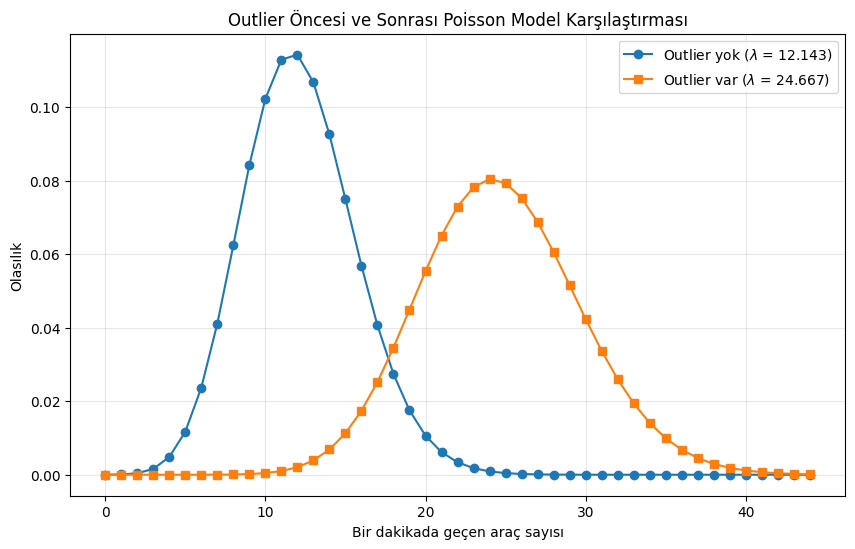

In [18]:
# Karşılaştırma grafiği
k_compare = np.arange(0, 45)

pmf_original = poisson.pmf(k_compare, mu=lambda_mle)
pmf_outlier = poisson.pmf(k_compare, mu=lambda_mle_outlier)

plt.figure(figsize=(10, 6))

plt.plot(
    k_compare,
    pmf_original,
    marker='o',
    label=f'Outlier yok ($\\lambda$ = {lambda_mle:.3f})'
)

plt.plot(
    k_compare,
    pmf_outlier,
    marker='s',
    label=f'Outlier var ($\\lambda$ = {lambda_mle_outlier:.3f})'
)

plt.xlabel("Bir dakikada geçen araç sayısı")
plt.ylabel("Olasılık")
plt.title("Outlier Öncesi ve Sonrası Poisson Model Karşılaştırması")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4.1 Outlier Yorumları

Aykırı değer eklenmeden önce $\lambda$ tahmini yaklaşık 12.14 iken, 200 değerinin eklenmesiyle
yaklaşık 24.67'ye yükselmiştir. Bu sonuç, Poisson dağılımında MLE tahmininin doğrudan ortalamaya
bağlı olması nedeniyle aykırı değerlere oldukça hassas olduğunu göstermektedir.

Bu hassasiyet belediyenin trafik planlamasında yanlış kararlara yol açabilir. Örneğin sistem,
normalden çok daha yüksek bir trafik yoğunluğu varmış gibi yorumlanabilir. Bunun sonucunda gereksiz
yol genişletme, hatalı kaynak dağılımı veya yanlış kapasite planlaması yapılabilir.

Dolayısıyla gerçek hayatta yalnızca MLE sonucuna bakmak yeterli değildir; veri temizleme,
aykırı değer kontrolü ve sağlam (robust) istatistiksel yöntemler de dikkate alınmalıdır.